<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/PLN/clasificacionDeTexto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                              review  sentimento
0  One of the other reviewers has mentioned that ...           1
1  A wonderful little production. <br /><br />The...           1
2  I thought this was a wonderful way to spend ti...           1
3  Basically there's a family where a little boy ...           0
4  Petter Mattei's "Love in the Time of Money" is...           1 

Columnas:  Index(['review', 'sentimento'], dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review       50000 non-null  object
 1   sentimiento  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB

 None

         sentimiento
count  50000.000000
mean       0.500000
std        0.500005
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000

Shape:  (50000, 2)

Nulos:
 revie

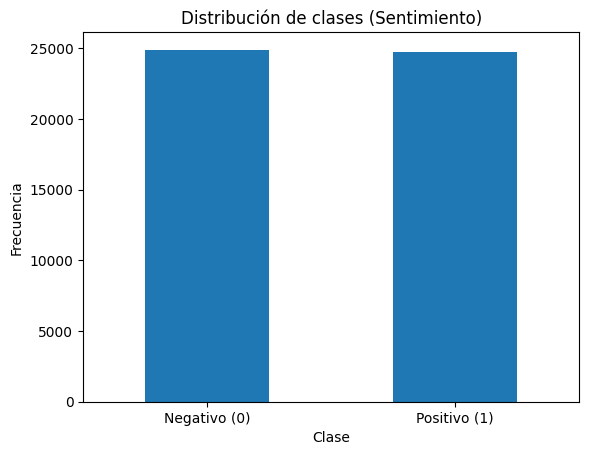


                                               review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                             cleaned  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...   


Datos de entrenamiento BoW: (39665, 202296) (39665,) Prueba BoW: (9917, 202296) (9917,)

Datos de entrenamiento TF-IDF: (39665, 202296) (39665,) Prueba TF-IDF: (9917, 202296) (9917,)

Evaluación con Bag of Words

Naive Bayes (BoW)


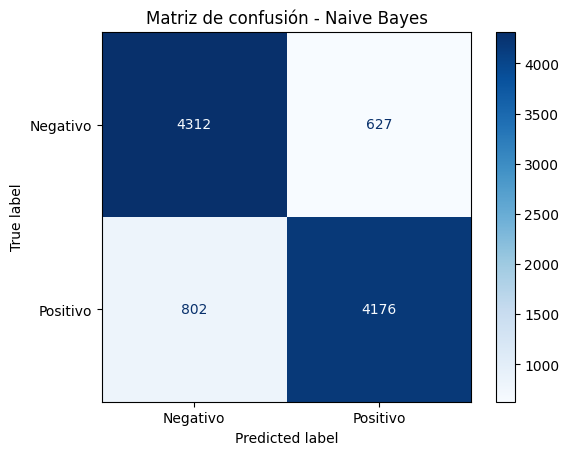


SVM (BoW)


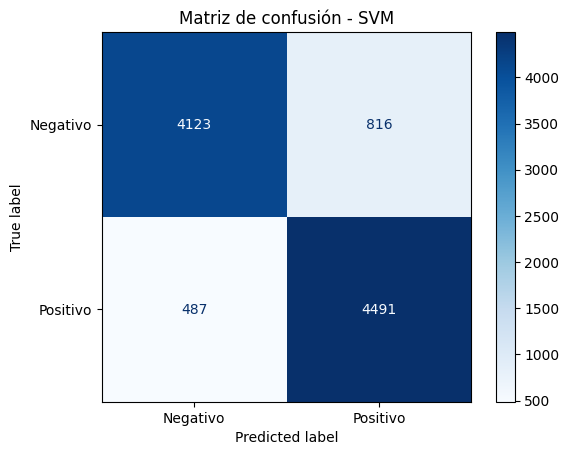


Random Forest (BoW)


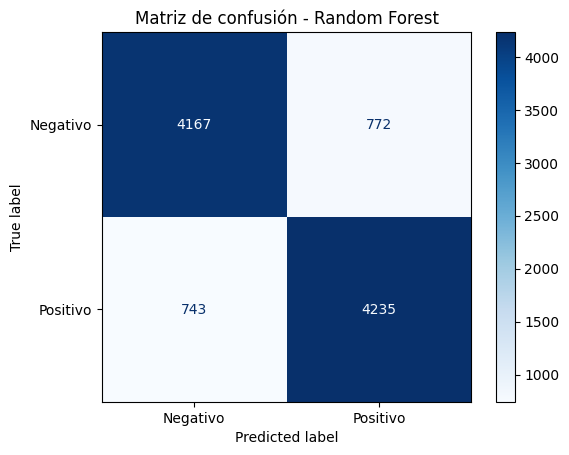


kNN (BoW)


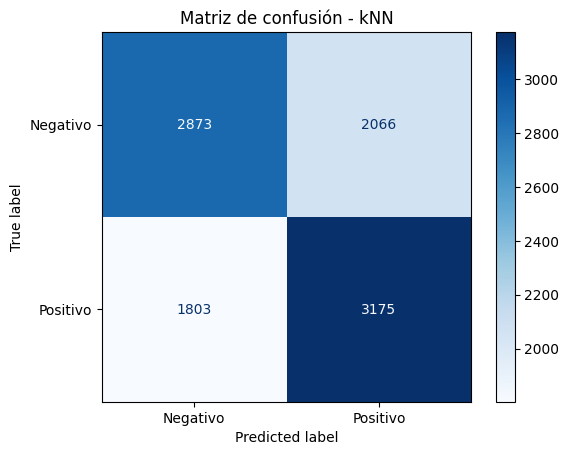


Logistic Regression (BoW)


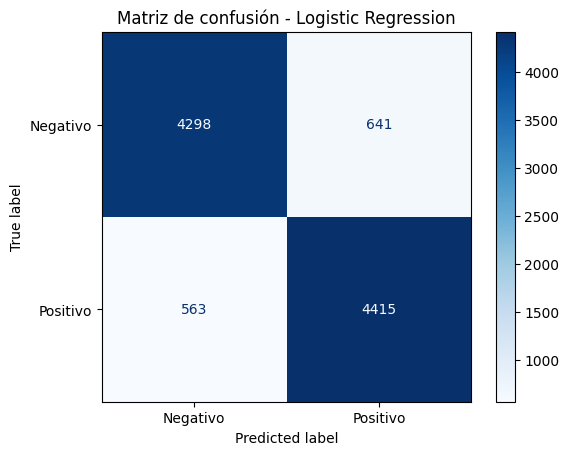


Evaluación con TF-IDF

Naive Bayes (TF-IDF)


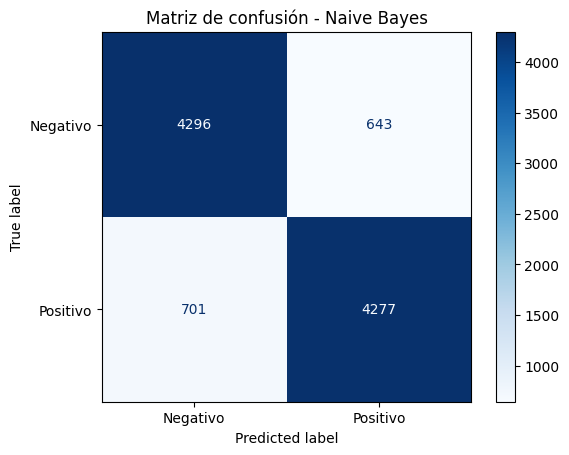


SVM (TF-IDF)


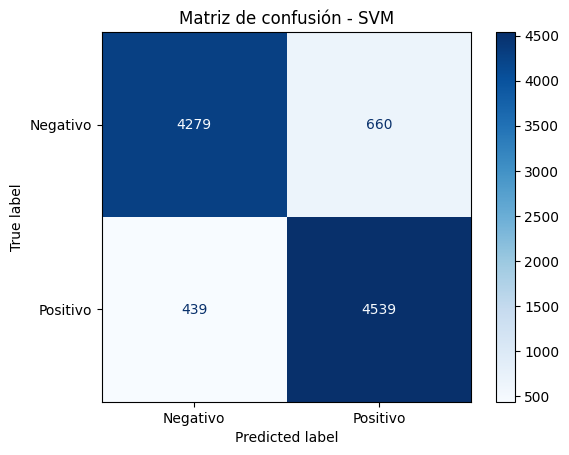


Random Forest (TF-IDF)


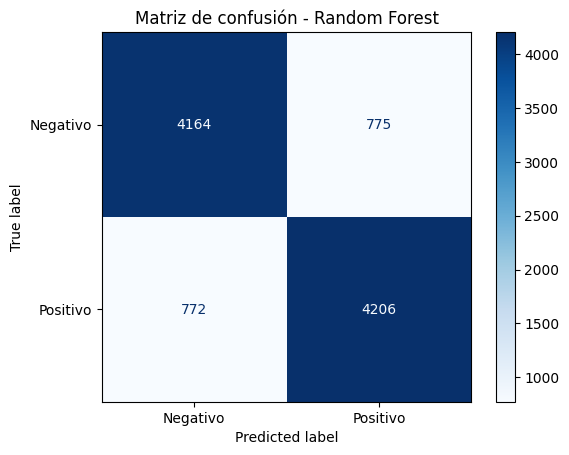


kNN (TF-IDF)


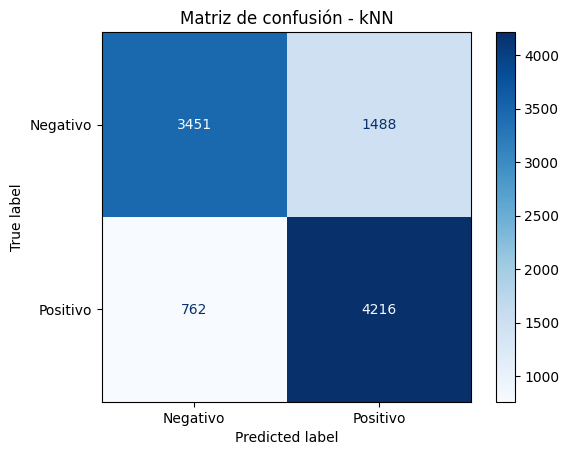


Logistic Regression (TF-IDF)


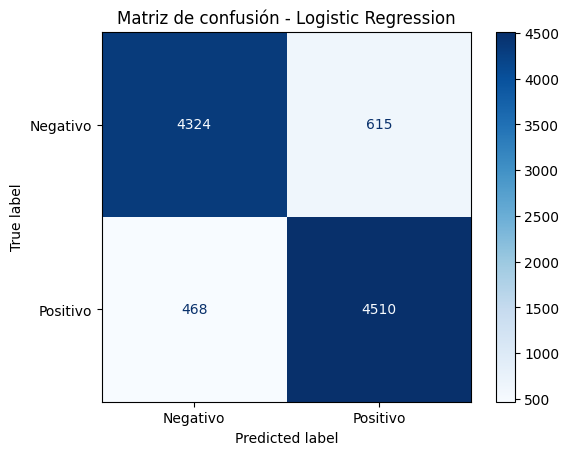


📊 Resultados Bag of Words:
                Modelo  Accuracy   AUC-ROC  Clase 0 - Precision  \
0          Naive Bayes  0.855904  0.921941             0.843176   
1                  SVM  0.868609  0.938719             0.894360   
2        Random Forest  0.847232  0.922616             0.848676   
3                  kNN  0.609862  0.647080             0.614414   
4  Logistic Regression  0.878592  0.944885             0.884180   

   Clase 0 - Recall  Clase 0 - F1  Clase 1 - Precision  Clase 1 - Recall  \
0          0.873051      0.857853             0.869457          0.838891   
1          0.834784      0.863546             0.846241          0.902170   
2          0.843693      0.846177             0.845816          0.850743   
3          0.581697      0.597608             0.605800          0.637806   
4          0.870217      0.877143             0.873220          0.886902   

   Clase 1 - F1  
0      0.853900  
1      0.873311  
2      0.848272  
3      0.621392  
4      0.880008  

📊 R

In [1]:
# librerías
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
import seaborn as sns

nltk.download('stopwords', quiet = True)
nltk.download('wordnet', quiet = True)
nltk.download('punkt', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Diccionario de modelos
modelos = {
    "Naive Bayes": MultinomialNB(),
    "SVM": SGDClassifier(loss="hinge", random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "kNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

df = pd.read_csv("/content/drive/MyDrive/ClassFiles/PLN/IMDB Reviews.csv")
print(df.head(),'\n')

# EDA
def eda(df):
  print('Columnas: ', df.columns, '\n')

  # renombrar columna
  df = df.rename(columns={'sentimento': 'sentimiento'})

  print('\n', df.info())

  print('\n', df.describe())

  # shape
  print('\nShape: ', df.shape)

  # nulos
  nulos = df.isnull().sum()
  print('\nNulos:\n', nulos)

  # na
  na = df.isna().sum()
  print('\nNA:\n', na)

  # duplicados
  duplicados = df.duplicated().sum() # duplicados
  print(f"Número de registros duplicados: {duplicados}")

  # Eliminar duplicados
  df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
  print("Nuevo shape después de eliminar duplicados:", df.shape)

  # balance
  df['sentimiento'].value_counts().plot(kind='bar')
  plt.title("Distribución de clases (Sentimiento)")
  plt.xlabel("Clase")
  plt.ylabel("Frecuencia")
  plt.xticks([0,1], ['Negativo (0)', 'Positivo (1)'], rotation=0)
  plt.show()

  return df

# Preprocesamiento
def preprocesamiento(texto):
  texto = texto.lower() # Convertir a minúsculas
  texto = re.sub(r'<.*?>', '', texto)  # quitar HTML
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto) # Eliminar URL
  texto = re.sub(r'[\w\._%+-]+@[\w.-]+\.[A-Za-z]{2,}', '', texto) # Eliminar email
  texto = re.sub(r'(?<!\w)@\w+', '', texto) # Eliminar menciones
  texto = re.sub(r'(?<!\w)#(\w+)', r'\1', texto)  # Reemplaza #hashtag por hashtag
  texto = re.sub(r'[^\w\s]', '', texto) # Eliminar puntuación
  texto = re.sub(r'\d+', '', texto)  # elimina números
  texto = re.sub(r'([aieou])\1+', r'\1', texto) # Eliminar vocales repetidas
  texto = re.sub(r'([bcdfghjklmnpqrstvwxyz])\1{2,}', r'\1', texto) # Eliminar consonantes repetidas
  texto = re.sub(r'\s+', ' ', texto).strip() # Eliminar espacios
  # tokenizar
  tokens = texto.split()
  # quitar stopwords y lematizar
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

  return ' '.join(tokens)

def entrenamiento(data):
  # Dividir los datos en conjuntos de entrenamiento y prueba
  X = data['cleaned']
  y = data['sentimiento']

  # Bag of Words
  bow_vectorizer = CountVectorizer()
  X_bow = bow_vectorizer.fit_transform(X)
  X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, y, test_size=0.2, random_state=42)

  # TF-IDF
  tfidf_vectorizer = TfidfVectorizer()
  X_tfidf = tfidf_vectorizer.fit_transform(X)
  X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

  return X_train_bow, X_test_bow, y_train_bow, y_test_bow, X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf

def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, pred)

    # Reporte por clase
    report = classification_report(y_test, pred, output_dict=True)

    # AUC-ROC (solo si el modelo soporta predict_proba o decision_function)
    try:
        if hasattr(modelo, "predict_proba"):
            proba = modelo.predict_proba(X_test)[:,1]
        else:
            proba = modelo.decision_function(X_test)
        auc = roc_auc_score(y_test, proba)
    except:
        auc = None

    # Matriz de confusión
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo","Positivo"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return {
        "Modelo": nombre,
        "Accuracy": acc,
        "AUC-ROC": auc,
        "Clase 0 - Precision": report["0"]["precision"],
        "Clase 0 - Recall": report["0"]["recall"],
        "Clase 0 - F1": report["0"]["f1-score"],
        "Clase 1 - Precision": report["1"]["precision"],
        "Clase 1 - Recall": report["1"]["recall"],
        "Clase 1 - F1": report["1"]["f1-score"]
    }

# Ejecutar
if __name__ == "__main__":
  # EDA
  df = eda(df)

  # Preprocesamiento
  df['cleaned'] = df['review'].astype(str).apply(preprocesamiento)
  print('\n', df[['review', 'cleaned']].head(), '\n')

  # Entrenamiento en BoW y TF-IDF
  X_entrena_bow, X_prueba_bow, y_entrena_bow, y_prueba_bow, X_entrena_tfidf, X_prueba_tfidf, y_entrena_tfidf, y_prueba_tfidf = entrenamiento(df)
  print('\nDatos de entrenamiento BoW:', X_entrena_bow.shape, y_entrena_bow.shape, 'Prueba BoW:',  X_prueba_bow.shape, y_prueba_bow.shape)
  print('\nDatos de entrenamiento TF-IDF:', X_entrena_tfidf.shape, y_entrena_tfidf.shape, 'Prueba TF-IDF:',  X_prueba_tfidf.shape, y_prueba_tfidf.shape)

  # Evaluación en BoW y TF-IDF
  resultados_bow = []
  resultados_tfidf = []

  # Evaluación en BoW
  print("\nEvaluación con Bag of Words")
  for nombre, modelo in modelos.items():
      print(f"\n{nombre} (BoW)")
      resultados_bow.append(
          evaluar_modelo(nombre, modelo,
                        X_entrena_bow, X_prueba_bow,
                        y_entrena_bow, y_prueba_bow)
      )

  # Evaluación en TF-IDF
  print("\nEvaluación con TF-IDF")
  for nombre, modelo in modelos.items():
      print(f"\n{nombre} (TF-IDF)")
      resultados_tfidf.append(
          evaluar_modelo(nombre, modelo,
                        X_entrena_tfidf, X_prueba_tfidf,
                        y_entrena_tfidf, y_prueba_tfidf)
      )

  # Pasar resultados a DataFrame
  resultados_bow_df = pd.DataFrame(resultados_bow)
  resultados_tfidf_df = pd.DataFrame(resultados_tfidf)

  print("\n📊 Resultados Bag of Words:")
  print(resultados_bow_df)

  print("\n📊 Resultados TF-IDF:")
  print(resultados_tfidf_df)
